# Day Ahead Energy Price Forecast

# ____________________ FOR GOOGLE COLAB ____________________

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Change the current working directory to the 'master_colab' folder on Google Drive
os.chdir('/content/drive/MyDrive/master_colab')

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/master_colab


# ____________________ FOR GOOGLE COLAB ____________________

In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import holidays
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_regression

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

import tensorflow as tf
from tensorflow.keras import layers, callbacks
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

import joblib
import pyarrow

import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
import gc
from cuml.ensemble import RandomForestRegressor as RFRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAXResults


# Load Data

In [4]:
data = pd.read_parquet("data/entsoe_price_and_loadfc.parquet")
weather_fc = pd.read_parquet("data/NOAA GFS/weather_forecast.parquet")
data = data.join(weather_fc, how="left")

# Feature Extraction

In [5]:
# lag features (use naive timestamp manipulation to avoid issues with DST transitions)
idx_naive = data.index.tz_localize(None)

prev_naive_day = idx_naive - pd.DateOffset(days=1)
prev_naive_day2 = idx_naive - pd.DateOffset(days=2)
prev_naive_week = idx_naive - pd.DateOffset(weeks=1)

idx_prev_day = prev_naive_day.tz_localize(
    "Europe/Berlin",
    ambiguous=False,
    nonexistent="shift_forward",
)
idx_prev_day2 = prev_naive_day2.tz_localize(
    "Europe/Berlin",
    ambiguous=False,
    nonexistent="shift_forward",
)
idx_prev_week = prev_naive_week.tz_localize(
    "Europe/Berlin",
    ambiguous=False,
    nonexistent="shift_forward",
)


data["price_lag_24h"] = data["da_price"].reindex(idx_prev_day).to_numpy()
data["price_lag_48h"] = data["da_price"].reindex(idx_prev_day2).to_numpy()
data["price_lag_168h"] = data["da_price"].reindex(idx_prev_week).to_numpy()


# weekday in local delivery time
data["weekday_sin"] = np.sin(2 * np.pi * data.index.dayofweek / 7)
data["weekday_cos"] = np.cos(2 * np.pi * data.index.dayofweek / 7)

# hour of local delivery day
data["hour_sin"] = np.sin(2 * np.pi * data.index.hour / 24)
data["hour_cos"] = np.cos(2 * np.pi * data.index.hour / 24)

# holiday not sunday in local delivery time
ger_holidays = list(holidays.Germany(years=data.index.year.unique()))
ger_holidays = pd.to_datetime(ger_holidays).tz_localize(data.index.tz)
data["holiday_not_sunday"] = (data.index.normalize().isin(ger_holidays) & (data.index.dayofweek != 6))

# remove all data outside of local delivery years 2023-2025 (only used for lag features)
data = data["2024":"2025"]

# Splitting

In [6]:
LOCAL_TZ = "Europe/Berlin"

TRAIN_START = pd.Timestamp("2024-01-01", tz=LOCAL_TZ)
TRAIN_END = pd.Timestamp("2025-07-01", tz=LOCAL_TZ)
TEST_START = pd.Timestamp("2025-07-01", tz=LOCAL_TZ)
TEST_END = pd.Timestamp("2026-01-01", tz=LOCAL_TZ)

train_mask = (data.index >= TRAIN_START) & (data.index < TRAIN_END)
test_mask = (data.index >= TEST_START) & (data.index < TEST_END)

data_train = data.loc[train_mask].copy()
data_test = data.loc[test_mask].copy()


split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "start": [data_train.index.min(), data_test.index.min()],
    "end": [data_train.index.max(), data_test.index.max()],
    "rows": [len(data_train), len(data_test)],
})
split_summary

,split,start,end,rows
0,train,2024-01-01 00:00:00+01:00,2025-06-30 23:00:00+02:00,13127
1,test,2025-07-01 00:00:00+02:00,2025-12-31 23:00:00+01:00,4417


# Modelling Setup

In [7]:
# ---------- General setup ----------

LOOKBACK = 168
HORIZON_STEPS = 1
TARGET_COL = "da_price"
FEATURE_COLS = ['load_fc',
                "ssrd",
                "tcc",
                "t2m",
                "rh2m",
                "U100",
                "sp",
                'price_lag_24h',
                'price_lag_48h',
                'price_lag_168h',
                'weekday_sin',
                'weekday_cos',
                'hour_sin',
                'hour_cos',
                'holiday_not_sunday']
SCALE_COLS = [
    c for c in FEATURE_COLS
    if c in ["load_fc", "price_lag_24h", "price_lag_48h", "price_lag_168h", "ssrd", "tcc", "t2m", "rh2m", "U100", "sp"]
]
LAG_COLS = [c for c in FEATURE_COLS if c.startswith("price_lag")]

# build datasets
model_df = data[[TARGET_COL] + FEATURE_COLS].copy()
train_df = model_df.loc[(model_df.index >= TRAIN_START) & (model_df.index < TRAIN_END)].copy()
test_df = model_df.loc[(model_df.index >= TEST_START) & (model_df.index < TEST_END)].copy()
## history data, cause lookback models need data for first hours in the test set, which have lookback windows reaching into the training period
test_history_df = model_df.loc[
    (model_df.index >= TEST_START - pd.Timedelta(hours=LOOKBACK)) & (model_df.index < TEST_START)
].copy()


# transformation functions for target variable price and the price lags (for robustness against outliers)
c = np.median(np.abs(train_df[TARGET_COL]))
def asinh_transform(y, c):
    return np.arcsinh(y / c)
def asinh_inverse(y_t, c):
    return c * np.sinh(y_t)
# raw truth
y_test = test_df[TARGET_COL].to_numpy(dtype=np.float32)

# apply asinh transformation
for col in [TARGET_COL] + LAG_COLS:
    train_df.loc[:, col] = asinh_transform(train_df[col], c)
    test_df.loc[:, col] = asinh_transform(test_df[col], c)
    test_history_df.loc[:, col] = asinh_transform(test_history_df[col], c)

# Feature scaling (RobustScaler)
scaler = RobustScaler()
train_df.loc[:, SCALE_COLS] = scaler.fit_transform(train_df[SCALE_COLS])
test_df.loc[:, SCALE_COLS] = scaler.transform(test_df[SCALE_COLS])
test_history_df.loc[:, SCALE_COLS] = scaler.transform(test_history_df[SCALE_COLS])

test_with_history_df = pd.concat([test_history_df, test_df], axis=0)

# error functions for model performance evaluation
def mae_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))
def rmse_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))





# ---------- No-Lookback setup: ----------

def build_point_dataset(df: pd.DataFrame, feature_cols: list[str], target_col: str):
    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32)
    ts = df.index
    return X, y, ts


X_train_point, y_train_point, ts_train_point = build_point_dataset(train_df, FEATURE_COLS, TARGET_COL)
X_test_point, y_test_point, ts_test_point = build_point_dataset(test_df, FEATURE_COLS, TARGET_COL)

display(pd.DataFrame([
    {"set": "point", "split": "train", "X": X_train_point.shape, "y": y_train_point.shape},
    {"set": "point", "split": "test", "X": X_test_point.shape, "y": y_test_point.shape},
]))




# ---------- Lookback setup ---------- :
# Fixed 168h window ending immediately before the local delivery day starts.
# All hours of the same local delivery day share the same price sequence.

SEQUENCE_COLS = [c for c in [TARGET_COL] if c in model_df.columns]


def _date_ints_from_index(index: pd.DatetimeIndex) -> np.ndarray:
    return np.array(
        [ts.year * 10000 + ts.month * 100 + ts.day for ts in index],
        dtype=np.int32,
    )


def build_lookback_dataset(
    df: pd.DataFrame,
    sequence_cols: list[str],
    exog_cols: list[str],
    target_col: str,
    lookback_hours: int,
):
    """
    For each target timestamp in local delivery day D, the lookback window covers
    the 168 rows ending immediately before D starts. This keeps all hours of the
    same local delivery day on the same fixed history window, including DST days
    with 23 or 25 delivery hours.
    """
    idx = df.index
    sequence_values = df[sequence_cols].to_numpy(dtype=np.float32)
    exog_values = df[exog_cols].to_numpy(dtype=np.float32)
    target_values = df[target_col].to_numpy(dtype=np.float32)
    date_ints = _date_ints_from_index(idx)

    first_pos_by_date = {}
    for pos, date_int in enumerate(date_ints):
        first_pos_by_date.setdefault(date_int, pos)

    X_seq, X_exog, y_target, ts_target = [], [], [], []

    for row_idx in range(len(df)):
        day_start_pos = first_pos_by_date[date_ints[row_idx]]
        keep_idx = np.arange(day_start_pos - lookback_hours, day_start_pos)
        if keep_idx[0] < 0:
            continue
        X_seq.append(sequence_values[keep_idx, :])
        X_exog.append(exog_values[row_idx])
        y_target.append(target_values[row_idx])
        ts_target.append(idx[row_idx])

    return (
        np.stack(X_seq),
        np.stack(X_exog),
        np.asarray(y_target, dtype=np.float32),
        pd.DatetimeIndex(ts_target),
    )


# --- build datasets ---
X_train_seq_lookback, X_train_exog_lookback, y_train_lookback, ts_train_lookback = build_lookback_dataset(
    train_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)

X_test_seq_lookback, X_test_exog_lookback, y_test_lookback, ts_test_lookback = build_lookback_dataset(
    test_with_history_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)
test_keep_mask = ts_test_lookback >= TEST_START
X_test_seq_lookback = X_test_seq_lookback[test_keep_mask]
X_test_exog_lookback = X_test_exog_lookback[test_keep_mask]
y_test_lookback = y_test_lookback[test_keep_mask]
ts_test_lookback = ts_test_lookback[test_keep_mask]

# flat layout for XGBoost
X_train_flat_lookback = np.concatenate([
    X_train_seq_lookback.reshape(X_train_seq_lookback.shape[0], -1),
    X_train_exog_lookback,
], axis=1)
X_test_flat_lookback = np.concatenate([
    X_test_seq_lookback.reshape(X_test_seq_lookback.shape[0], -1),
    X_test_exog_lookback,
], axis=1)

display(pd.DataFrame([
    {"set": "fixed lookback", "split": "train", "X_seq": X_train_seq_lookback.shape, "X_exog": X_train_exog_lookback.shape, "X_flat": X_train_flat_lookback.shape, "y": y_train_lookback.shape},
    {"set": "fixed lookback", "split": "test",  "X_seq": X_test_seq_lookback.shape,  "X_exog": X_test_exog_lookback.shape,  "X_flat": X_test_flat_lookback.shape,  "y": y_test_lookback.shape},
]))

,set,split,X,y
0,point,train,"(13127, 15)","(13127,)"
1,point,test,"(4417, 15)","(4417,)"


,set,split,X_seq,X_exog,X_flat,y
0,fixed lookback,train,"(12959, 168, 1)","(12959, 15)","(12959, 183)","(12959,)"
1,fixed lookback,test,"(4417, 168, 1)","(4417, 15)","(4417, 183)","(4417,)"


# Feature Selection

### Feature Exploration

In [ ]:
# define data frame
feature_eval = pd.DataFrame(index=FEATURE_COLS)

# add correlation with price
feature_eval["corr_with_price"] = [train_df["da_price"].corr(train_df[c]) for c in FEATURE_COLS]

# add mutual information with price
clean_for_mi = train_df[["da_price"] + FEATURE_COLS].copy()
X_mi = clean_for_mi[FEATURE_COLS].copy()
X_mi["holiday_not_sunday"] = X_mi["holiday_not_sunday"].astype(int)
mi = mutual_info_regression(X_mi, clean_for_mi["da_price"], random_state=1904)
feature_eval["mutual_info"] = mi

# special cases for sin/cos decoded features
## vektor norm for correlation columns
feature_eval.loc["hour"] = feature_eval.loc[["hour_sin", "hour_cos"]].max()
feature_eval.loc["hour", "corr_with_price"] = np.sqrt(
    feature_eval.loc["hour_sin", "corr_with_price"] ** 2 + feature_eval.loc["hour_cos", "corr_with_price"] ** 2
)
feature_eval.loc["weekday"] = feature_eval.loc[["weekday_sin", "weekday_cos"]].max()
feature_eval.loc["weekday", "corr_with_price"] = np.sqrt(
    feature_eval.loc["weekday_sin", "corr_with_price"] ** 2 + feature_eval.loc["weekday_cos", "corr_with_price"] ** 2
)
## mutual information with simple discrete encoding
mi_hour = mutual_info_regression(
    train_df.index.hour.values.reshape(-1, 1),
    train_df["da_price"],
    discrete_features=True,
    random_state=1904
)[0]
feature_eval.loc["hour", "mutual_info"] = mi_hour
mi_weekday = mutual_info_regression(
    train_df.index.dayofweek.values.reshape(-1, 1),
    train_df["da_price"],
    discrete_features=True,
    random_state=1904
)[0]
feature_eval.loc["weekday", "mutual_info"] = mi_weekday

# add year-wise correlation with price to check for stability across years
for y in [2024, 2025]:
    y_mask = train_df.index.year == y
    year_corr = pd.Series({
        c: train_df.loc[y_mask, "da_price"].corr(train_df.loc[y_mask, c]) for c in FEATURE_COLS
    })
    feature_eval[f"corr_{y}"] = year_corr
    feature_eval.loc["hour", f"corr_{y}"] = np.sqrt(
        feature_eval.loc["hour_sin", f"corr_{y}"] ** 2 + feature_eval.loc["hour_cos", f"corr_{y}"] ** 2
    )
    feature_eval.loc["weekday", f"corr_{y}"] = np.sqrt(
        feature_eval.loc["weekday_sin", f"corr_{y}"] ** 2 + feature_eval.loc["weekday_cos", f"corr_{y}"] ** 2
    )
corr_cols = ["corr_2024", "corr_2025"]
feature_eval["corr_std_across_years"] = feature_eval[corr_cols].std(axis=1)

# remove rows of cyclic encodings
feature_eval = feature_eval.drop(index=["hour_sin", "hour_cos", "weekday_sin", "weekday_cos"])

# display results
display("All price features in the following tables are asinh-transformed.",
"The variables weekday and hour are cyclic encoded. " \
"To have a single value for the correlation the vector norm is used and for the mutual information simple discrete encoding is used.",
feature_eval)

'All price features in the following tables are asinh-transformed.'

'The variables weekday and hour are cyclic encoded. To have a single value for the correlation the vector norm is used and for the mutual information simple discrete encoding is used.'

,corr_with_price,mutual_info,corr_2024,corr_2025,corr_std_across_years
load_fc,0.2266,0.1332,0.2277,0.2134,0.0101
ssrd,-0.3787,0.1390,-0.2935,-0.5263,0.1646
tcc,-0.0649,0.0503,-0.1111,0.0456,0.1108
t2m,-0.3374,0.1270,-0.2117,-0.5255,0.2219
rh2m,0.3536,0.1097,0.3079,0.4791,0.1210
U100,-0.3955,0.1485,-0.4205,-0.3433,0.0546
sp,0.2319,0.1113,0.2450,0.1808,0.0454
price_lag_24h,0.6915,0.4590,0.6414,0.7553,0.0806
price_lag_48h,0.5454,0.2846,0.4630,0.6518,0.1335
price_lag_168h,0.5807,0.3086,0.5304,0.6420,0.0789


Weather features: *ssrd* und *U100* have highest correlation and mutual information.

All features have relatively low std across the two years.

*holiday_not_sunday* has a notably low correlation and mutual information. Maybe not necessary variable for modelation.

### Feature Importance Rankings


── Feature Selection Ranking ──
                    xgb_gain  lasso_abs_coef
load_fc               0.1110          1.0000
ssrd                  0.1760          0.2620
tcc                   0.0010          0.0000
t2m                   0.0300          0.0090
rh2m                  0.0930          0.3820
U100                  0.2540          0.8440
sp                    0.0000          0.0380
price_lag_24h         1.0000          0.4550
price_lag_48h         0.0160          0.1750
price_lag_168h        0.1070          0.3180
holiday_not_sunday    0.1070          0.0000
hour                  0.1930          0.4170
weekday               0.1010          0.1540


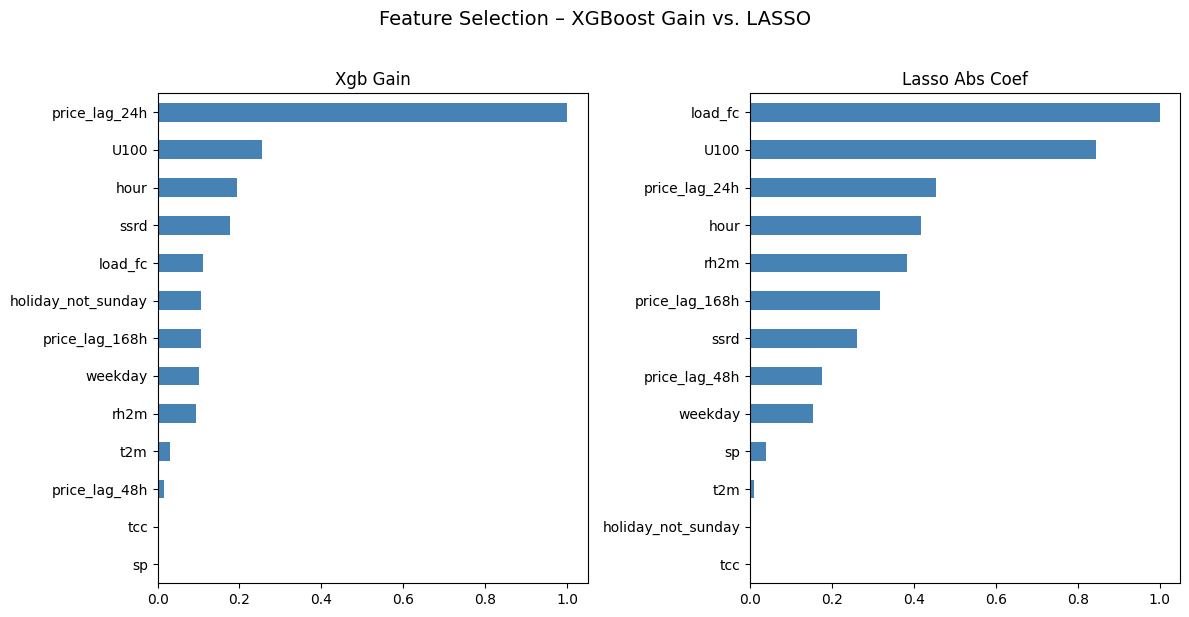

In [ ]:
# ── Feature Selection: Embedded & Wrapper Methods ──────────────────────────
from sklearn.linear_model import LassoCV
from xgboost import XGBRegressor

# ── Zyklische Feature-Gruppen ──
cyclic_pairs = {
    "hour":    ["hour_sin", "hour_cos"],
    "weekday": ["weekday_sin", "weekday_cos"],
}
single_features = [f for f in FEATURE_COLS if not any(f in pair for pair in cyclic_pairs.values())]
display_names = single_features + list(cyclic_pairs.keys())

col_idx = {f: i for i, f in enumerate(FEATURE_COLS)}


# ── 1) XGBoost Feature Importance (gain) ──
xgb_fs = XGBRegressor(random_state=1904, n_jobs=-1)
xgb_fs.fit(X_train_point, y_train_point)

raw_xgb = pd.Series(xgb_fs.feature_importances_, index=FEATURE_COLS)
xgb_importance = pd.Series(dtype=float, name="xgb_gain")
for f in single_features:
    xgb_importance[f] = raw_xgb[f]
for name, cols in cyclic_pairs.items():
    xgb_importance[name] = np.sqrt((raw_xgb[cols] ** 2).sum())


# ── 2) LASSO (L1-Regularisierung) ──
lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=1904, n_jobs=-1)
lasso.fit(X_train_point, y_train_point)

raw_lasso = pd.Series(np.abs(lasso.coef_), index=FEATURE_COLS)
lasso_coefs = pd.Series(dtype=float, name="lasso_abs_coef")
for f in single_features:
    lasso_coefs[f] = raw_lasso[f]
for name, cols in cyclic_pairs.items():
    lasso_coefs[name] = np.sqrt((raw_lasso[cols] ** 2).sum())


# ── Ranking ──────────────────────────────────────────────────
fs_results = pd.DataFrame({
    "xgb_gain":       xgb_importance,
    "lasso_abs_coef": lasso_coefs,
}, index=display_names)

fs_norm = fs_results.apply(lambda col: (col - col.min()) / (col.max() - col.min()))

print("\n── Feature Selection Ranking ──")
print(fs_norm.round(3).to_string())

# ── Visualisierung ──
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, col in zip(axes, fs_norm.columns):
    fs_norm[col].sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlim(0, 1.05)
axes[0].set_ylabel("")
fig.suptitle("Feature Selection – XGBoost Gain vs. LASSO", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Recursive Feature Elimination


Config: default — sklearn defaults
All 13 features → CV-MAE: 0.1653
  Best candidate: 'rh2m' → CV-MAE: 0.1647  (Δ = -0.0005)
    → Removed. Remaining: ['load_fc', 'ssrd', 'tcc', 't2m', 'U100', 'sp', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Best candidate: 't2m' → CV-MAE: 0.1667  (Δ = +0.0020)
    → No improvement. Stopping.
Final features (12): ['load_fc', 'ssrd', 'tcc', 't2m', 'U100', 'sp', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']

Config: deep_slow — {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
All 13 features → CV-MAE: 0.1592
  Best candidate: 'rh2m' → CV-MAE: 0.1571  (Δ = -0.0022)
    → Removed. Remaining: ['load_fc', 'ssrd', 'tcc', 't2m', 'U100', 'sp', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Best candidate: 't2m' → CV-MAE: 0.1563  (Δ = -0.0008)
    → Removed. Rema

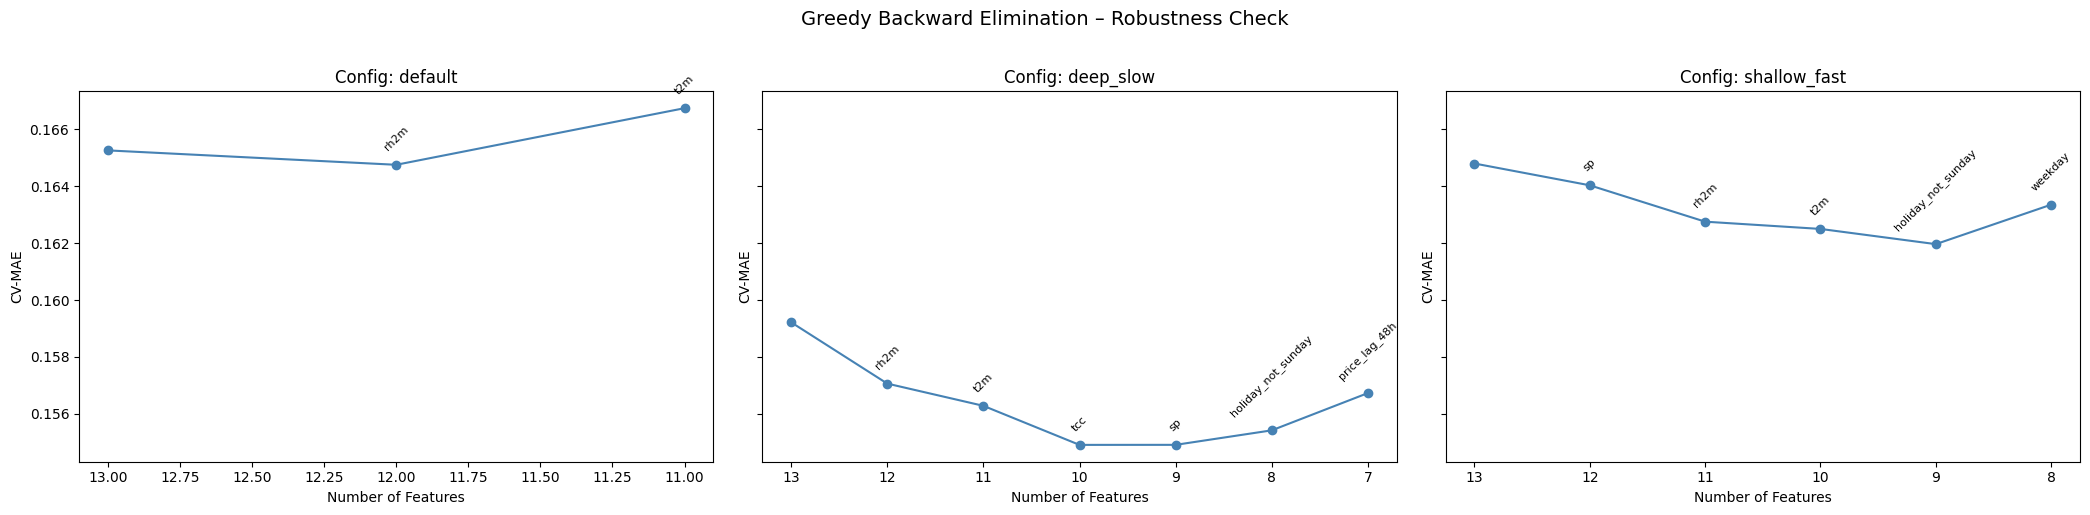

In [ ]:
# ── Greedy Backward Elimination with CV (Multi-Config) ──────────────────────
from sklearn.model_selection import cross_val_score
from collections import Counter

tscv = TimeSeriesSplit(n_splits=5)

def get_col_indices(selected_names):
    indices = []
    for name in selected_names:
        if name in cyclic_pairs:
            indices += [col_idx[c] for c in cyclic_pairs[name]]
        else:
            indices.append(col_idx[name])
    return indices

configs = [
    {"label": "default",      "params": {}},
    {"label": "deep_slow",    "params": {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8}},
    {"label": "shallow_fast", "params": {"n_estimators": 200, "max_depth": 8, "learning_rate": 0.1}},
]

all_results = {}

for cfg in configs:
    label = cfg["label"]
    print(f"\n{'='*60}")
    print(f"Config: {label} — {cfg['params'] or 'sklearn defaults'}")
    print(f"{'='*60}")

    def cv_mae_for_features(selected_names):
        idx = get_col_indices(selected_names)
        return -cross_val_score(
            XGBRegressor(
                objective="reg:squarederror", random_state=1904, n_jobs=-1,
                **cfg["params"],
            ),
            X_train_point[:, idx], y_train_point,
            cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1,
        ).mean()

    remaining = display_names.copy()
    current_score = cv_mae_for_features(remaining)
    elimination_log = [{"n_features": len(remaining), "removed": None, "cv_mae": current_score}]
    print(f"All {len(remaining)} features → CV-MAE: {current_score:.4f}")

    while len(remaining) > 1:
        trials = []
        for candidate in remaining:
            trial = [f for f in remaining if f != candidate]
            score = cv_mae_for_features(trial)
            trials.append((candidate, score, trial))

        best_candidate, best_score, best_trial = min(trials, key=lambda x: x[1])
        elimination_log.append({"n_features": len(best_trial), "removed": best_candidate, "cv_mae": best_score})

        print(f"  Best candidate: '{best_candidate}' → CV-MAE: {best_score:.4f}  (Δ = {best_score - current_score:+.4f})")

        if best_score <= current_score * 1.005:
            remaining = best_trial
            current_score = best_score
            print(f"    → Removed. Remaining: {remaining}")
        else:
            print(f"    → No improvement. Stopping.")
            break

    all_results[label] = {
        "remaining": remaining,
        "log": pd.DataFrame(elimination_log),
    }
    print(f"Final features ({len(remaining)}): {remaining}")


# ── Summary: how often was each feature removed? ──

removed_counts = Counter()
for label, result in all_results.items():
    removed_in_config = set(display_names) - set(result["remaining"])
    removed_counts.update(removed_in_config)

print(f"\n{'='*60}")
for f in display_names:
    count = removed_counts.get(f, 0)
    if count > 0:
        print(f"  {f}: removed in {count}/{len(configs)} configs")
print(f"{'='*60}")



# ── Visualization ──
fig, axes = plt.subplots(1, len(configs), figsize=(7 * len(configs), 5), sharey=True)
for ax, (label, result) in zip(axes, all_results.items()):
    log_df = result["log"]
    ax.plot(log_df["n_features"], log_df["cv_mae"], "o-", color="steelblue")
    for _, row in log_df.iterrows():
        if row["removed"]:
            ax.annotate(row["removed"], (row["n_features"], row["cv_mae"]),
                        textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center", rotation=45)
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("CV-MAE")
    ax.set_title(f"Config: {label}")
    ax.invert_xaxis()
fig.suptitle("Greedy Backward Elimination – Robustness Check", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The weather features *t2m*, *sp*, *tcc* and *rh2m* have a lack of importance to the basic models. Only the weather features *U100* and *ssrd* will be kept for the modeling and work as proxies for the wind generation (*U100*) and solar generation (*ssrd*).

The feature *holiday_not_sunday* will also be deleted, as it got removed in 2 out of three configs and also has a low abs. correlation with the price, a low mutual information and a low abs. lasso coefficient.

### Delete Features

In [8]:
# ── Gewählte Variablen aus bestehenden Objekten entfernen ───────────────────
DROP_COLS = ["t2m", "sp", "tcc", "rh2m", "holiday_not_sunday"]

# Alte Reihenfolge merken, weil die bestehenden Arrays noch darauf basieren
old_feature_cols = FEATURE_COLS.copy()

# Behaltene Features + zugehörige Indizes
keep_cols = [c for c in old_feature_cols if c not in DROP_COLS]
keep_idx = [old_feature_cols.index(c) for c in keep_cols]

# Listen aktualisieren
FEATURE_COLS = keep_cols
SCALE_COLS = [c for c in SCALE_COLS if c not in DROP_COLS]

# DataFrames aktualisieren
model_df = model_df.drop(columns=DROP_COLS)
train_df = train_df.drop(columns=DROP_COLS)
test_df = test_df.drop(columns=DROP_COLS)
test_history_df = test_history_df.drop(columns=DROP_COLS)
test_with_history_df = test_with_history_df.drop(columns=DROP_COLS)

# Point-Datasets aktualisieren
X_train_point = X_train_point[:, keep_idx]
X_test_point = X_test_point[:, keep_idx]

# Lookback-Exog-Datasets aktualisieren
X_train_exog_lookback = X_train_exog_lookback[:, keep_idx]
X_test_exog_lookback = X_test_exog_lookback[:, keep_idx]

# Flat-Lookback-Datasets neu zusammensetzen
X_train_flat_lookback = np.concatenate([
    X_train_seq_lookback.reshape(X_train_seq_lookback.shape[0], -1),
    X_train_exog_lookback,
], axis=1)

X_test_flat_lookback = np.concatenate([
    X_test_seq_lookback.reshape(X_test_seq_lookback.shape[0], -1),
    X_test_exog_lookback,
], axis=1)

display(pd.DataFrame([
    {"set": "point", "split": "train", "X": X_train_point.shape, "y": y_train_point.shape},
    {"set": "point", "split": "test", "X": X_test_point.shape, "y": y_test_point.shape},
]))
display(pd.DataFrame([
    {"set": "fixed lookback", "split": "train", "X_seq": X_train_seq_lookback.shape, "X_exog": X_train_exog_lookback.shape, "X_flat": X_train_flat_lookback.shape, "y": y_train_lookback.shape},
    {"set": "fixed lookback", "split": "test",  "X_seq": X_test_seq_lookback.shape,  "X_exog": X_test_exog_lookback.shape,  "X_flat": X_test_flat_lookback.shape,  "y": y_test_lookback.shape},
]))


,set,split,X,y
0,point,train,"(13127, 10)","(13127,)"
1,point,test,"(4417, 10)","(4417,)"


,set,split,X_seq,X_exog,X_flat,y
0,fixed lookback,train,"(12959, 168, 1)","(12959, 10)","(12959, 178)","(12959,)"
1,fixed lookback,test,"(4417, 168, 1)","(4417, 10)","(4417, 178)","(4417,)"


## Rollout Lookback Modelling Setup

In [9]:
# ---------- Rollout-Lookback setup ----------
# Rolling 168h window ending one hour before the target timestamp.
# Rollout models are trained on the same rolling-window layout.
# During test rollout, same-day target values are replaced by earlier predictions.

ROLL_PRICE_COL = "_roll_price"


def to_numpy_float32(values) -> np.ndarray:
    if hasattr(values, "to_numpy"):
        values = values.to_numpy()
    if hasattr(values, "get"):
        values = values.get()
    return np.asarray(values, dtype=np.float32).reshape(-1)


def _date_ints(index: pd.DatetimeIndex) -> np.ndarray:
    return np.array(
        [ts.year * 10000 + ts.month * 100 + ts.day for ts in index],
        dtype=np.int32,
    )


def _steps_within_day(index: pd.DatetimeIndex) -> np.ndarray:
    date_ints = _date_ints(index)
    steps = np.empty(len(index), dtype=np.int32)
    previous_date = None
    step = -1

    for i, date_int in enumerate(date_ints):
        if date_int != previous_date:
            previous_date = date_int
            step = 0
        else:
            step += 1
        steps[i] = step

    return steps


def build_rolling_lookback_dataset(
    df: pd.DataFrame,
    sequence_cols: list[str],
    exog_cols: list[str],
    target_col: str,
    lookback_hours: int,
):
    """
    For each target timestamp ts, the sequence covers the last `lookback_hours`
    rows ending at ts - 1h. This is the training layout used by rollout models.
    """
    idx = df.index
    sequence_values = df[sequence_cols].to_numpy(dtype=np.float32)
    exog_values = df[exog_cols].to_numpy(dtype=np.float32)
    target_values = df[target_col].to_numpy(dtype=np.float32)

    X_seq, X_exog, y_target, ts_target = [], [], [], []

    for row_idx in range(lookback_hours, len(df)):
        keep_idx = np.arange(row_idx - lookback_hours, row_idx)
        X_seq.append(sequence_values[keep_idx, :])
        X_exog.append(exog_values[row_idx])
        y_target.append(target_values[row_idx])
        ts_target.append(idx[row_idx])

    return (
        np.stack(X_seq),
        np.stack(X_exog),
        np.asarray(y_target, dtype=np.float32),
        pd.DatetimeIndex(ts_target),
    )


def build_rollout_frame(
    history_df: pd.DataFrame,
    target_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
) -> pd.DataFrame:
    rollout = pd.concat(
        [
            history_df[[target_col]],
            target_df[[target_col] + feature_cols],
        ],
        axis=0,
    ).sort_index()

    if not rollout.index.is_unique:
        raise ValueError("rollout_df index must be unique.")
    if rollout[target_col].isna().any():
        raise ValueError("rollout_df target contains missing values.")

    rollout[ROLL_PRICE_COL] = rollout[target_col].astype(np.float32)
    rollout.loc[target_df.index, ROLL_PRICE_COL] = np.nan
    return rollout


def _rollout_predict(
    rollout_df: pd.DataFrame,
    target_times: pd.DatetimeIndex,
    feature_cols: list[str],
    target_col: str,
    lookback_hours: int,
    predict_batch,
    verbose: bool = False,
) -> np.ndarray:
    target_times = pd.DatetimeIndex(target_times)
    if len(target_times) == 0:
        return np.array([], dtype=np.float32)
    if not target_times.is_monotonic_increasing:
        raise ValueError("target_times must be sorted increasingly for rollout prediction.")

    idx_lookup = {ts: i for i, ts in enumerate(rollout_df.index)}
    missing_times = [ts for ts in target_times if ts not in idx_lookup]
    if missing_times:
        raise KeyError(f"target timestamp missing from rollout_df: {missing_times[0]}")

    target_pos = np.array([idx_lookup[ts] for ts in target_times], dtype=np.int64)
    if np.any(target_pos < lookback_hours):
        raise ValueError("rollout_df does not contain enough history for the requested lookback.")

    roll_price = rollout_df[ROLL_PRICE_COL].to_numpy(dtype=np.float32).copy()
    target_arr = rollout_df[target_col].to_numpy(dtype=np.float32)
    exog_arr = rollout_df[feature_cols].to_numpy(dtype=np.float32)
    date_ints = _date_ints(rollout_df.index)
    target_date_ints = _date_ints(target_times)
    target_steps = _steps_within_day(target_times)

    preds = np.zeros(len(target_times), dtype=np.float32)
    lookback_offsets = np.arange(-lookback_hours, 0, dtype=np.int64)
    max_step = int(target_steps.max())

    for step in range(max_step + 1):
        band = np.flatnonzero(target_steps == step)
        if len(band) == 0:
            continue

        pos = target_pos[band]
        hist_pos = pos[:, None] + lookback_offsets
        same_day = date_ints[hist_pos] == target_date_ints[band, None]

        seq = np.where(same_day, roll_price[hist_pos], target_arr[hist_pos]).astype(np.float32)
        if np.isnan(seq).any():
            raise ValueError(
                "Rollout sequence contains NaN. target_times must include previous same-day targets."
            )
        exog = exog_arr[pos].astype(np.float32)

        y_hat = to_numpy_float32(predict_batch(seq, exog))
        if len(y_hat) != len(band):
            raise ValueError("Rollout model returned an unexpected number of predictions.")

        preds[band] = y_hat
        roll_price[pos] = y_hat

        if verbose:
            print(f"  Rollout step {step + 1:02d}/{max_step + 1:02d} - {len(band)} samples")

    return preds


def rollout_predict_tabular(
    model,
    rollout_df: pd.DataFrame,
    target_times: pd.DatetimeIndex,
    feature_cols: list[str],
    target_col: str,
    lookback_hours: int,
    verbose: bool = False,
) -> np.ndarray:
    def predict_batch(seq: np.ndarray, exog: np.ndarray):
        x_batch = np.concatenate([seq, exog], axis=1).astype(np.float32)
        return model.predict(x_batch)

    return _rollout_predict(
        rollout_df,
        target_times,
        feature_cols,
        target_col,
        lookback_hours,
        predict_batch,
        verbose=verbose,
    )


def rollout_predict_keras(
    model,
    rollout_df: pd.DataFrame,
    target_times: pd.DatetimeIndex,
    feature_cols: list[str],
    target_col: str,
    lookback_hours: int,
    verbose: bool = False,
) -> np.ndarray:
    def predict_batch(seq: np.ndarray, exog: np.ndarray):
        keras_inputs = [seq[:, :, None], exog]
        try:
            return model.predict(keras_inputs, verbose=0)
        except TypeError:
            return model.predict(keras_inputs)

    return _rollout_predict(
        rollout_df,
        target_times,
        feature_cols,
        target_col,
        lookback_hours,
        predict_batch,
        verbose=verbose,
    )


# Backwards-compatible aliases for the original draft names.
rollout_predict_xgb = rollout_predict_tabular
rollout_predict_lstm = rollout_predict_keras


# --- build rolling-lookback datasets for rollout models ---
X_train_seq_rollout, X_train_exog_rollout, y_train_rollout, ts_train_rollout = build_rolling_lookback_dataset(
    train_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)

X_test_seq_rollout, X_test_exog_rollout, y_test_rollout_t, ts_test_rollout = build_rolling_lookback_dataset(
    test_with_history_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)
rollout_keep_mask = ts_test_rollout >= TEST_START
X_test_seq_rollout = X_test_seq_rollout[rollout_keep_mask]
X_test_exog_rollout = X_test_exog_rollout[rollout_keep_mask]
y_test_rollout_t = y_test_rollout_t[rollout_keep_mask]
ts_test_rollout = ts_test_rollout[rollout_keep_mask]

X_train_flat_rollout = np.concatenate([
    X_train_seq_rollout.reshape(X_train_seq_rollout.shape[0], -1),
    X_train_exog_rollout,
], axis=1)
X_test_flat_rollout = np.concatenate([
    X_test_seq_rollout.reshape(X_test_seq_rollout.shape[0], -1),
    X_test_exog_rollout,
], axis=1)

rollout_df = build_rollout_frame(test_history_df, test_df, FEATURE_COLS, TARGET_COL)
test_rollout_index = ts_test_rollout
y_test_rollout = y_test


display(pd.DataFrame([
    {"set": "rollout", "split": "train", "X_seq": X_train_seq_rollout.shape, "X_exog": X_train_exog_rollout.shape, "X_flat": X_train_flat_rollout.shape, "y": y_train_rollout.shape},
    {"set": "rollout", "split": "test", "X_seq": X_test_seq_rollout.shape, "X_exog": X_test_exog_rollout.shape, "X_flat": X_test_flat_rollout.shape, "y": y_test_rollout_t.shape},
]))

,set,split,X_seq,X_exog,X_flat,y
0,rollout,train,"(12959, 168, 1)","(12959, 10)","(12959, 178)","(12959,)"
1,rollout,test,"(4417, 168, 1)","(4417, 10)","(4417, 178)","(4417,)"


# SARIMAX pre-diagnostic for hyperparameter definition

In [ ]:
# ── Simple pre-diagnostic: decide differencing + derive a compact grid ──
# Idea: we only decide HOW OFTEN to difference (d, D) from the data.
# The exact AR/MA orders (p, q, P, Q) are left to the AIC grid search,
# but deliberately restricted to small values.

from statsmodels.tsa.stattools import adfuller, kpss
from itertools import product

S = 24  # daily seasonality for hourly data
y = train_df[TARGET_COL]


def is_stationary(series):
    """A series counts as stationary only if ADF AND KPSS agree."""
    adf_p = adfuller(series.dropna())[1]              # H0: non-stationary -> p < 0.05 = stationary
    kpss_p = kpss(series.dropna(), nlags="auto")[1]   # H0: stationary     -> p > 0.05 = stationary
    return (adf_p < 0.05) and (kpss_p > 0.05), adf_p, kpss_p


# Decide differencing: seasonal first (against the daily pattern), then regular if needed.
stat_orig, adf0, kpss0 = is_stationary(y)
stat_seas, adf1, kpss1 = is_stationary(y.diff(S).dropna())

d, D = 0, 0
if not stat_orig:
    D = 1                 # seasonal differencing against the daily seasonality
    if not stat_seas:
        d = 1             # additional regular differencing if still not stationary

print(f"Original     : stationary={stat_orig}  (ADF p={adf0:.3f}, KPSS p={kpss0:.3f})")
print(f"Seasonal diff: stationary={stat_seas}  (ADF p={adf1:.3f}, KPSS p={kpss1:.3f})")
print(f"=> chosen differencing: d={d}, D={D}, s={S}\n")

# Compact grid for the AR/MA orders.
search_space = sorted(
    (p, q, P, Q)
    for p, q, P, Q in product([0, 1, 2], [0, 1, 2], [0, 1], [0, 1])    # initial grid with common sense limits to avoid long runtimes
    if (p + q) <= 2 and (P + Q) <= 1                                   # keep the model lean (no overfitting) by limiting total AR+MA orders
    and not ((p >= 2 and P >= 1) or (q >= 2 and Q >= 1))               # avoid known over-parameterization patterns (high non-seasonal + seasonal orders together
)

print(f"Search grid: d={d}, D={D}, s={S}, {len(search_space)} candidates (p,q,P,Q):")
print(search_space)


/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_40828/2070867218.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series.dropna(), nlags="auto")[1]   # H0: stationary     -> p > 0.05 = stationary


Original     : stationary=False  (ADF p=0.000, KPSS p=0.010)
Seasonal diff: stationary=True  (ADF p=0.000, KPSS p=0.100)
=> chosen differencing: d=0, D=1, s=24

Search grid: d=0, D=1, s=24, 16 candidates (p,q,P,Q):
[(0, 0, 0, 0), (0, 0, 0, 1), (0, 0, 1, 0), (0, 1, 0, 0), (0, 1, 0, 1), (0, 1, 1, 0), (0, 2, 0, 0), (0, 2, 1, 0), (1, 0, 0, 0), (1, 0, 0, 1), (1, 0, 1, 0), (1, 1, 0, 0), (1, 1, 0, 1), (1, 1, 1, 0), (2, 0, 0, 0), (2, 0, 0, 1)]


/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_40828/2070867218.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series.dropna(), nlags="auto")[1]   # H0: stationary     -> p > 0.05 = stationary


# **************** MODELLING ****************

## ____________________ XGBoost ____________________




In [ ]:
xgb_base = dict(
    objective="reg:squarederror",
    random_state=1904,
    n_jobs=-1,
    device="cuda"
)

param_dist = {
    "n_estimators": [100, 200, 400, 500],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "min_child_weight": [1, 3, 5, 7],
}

In [ ]:
# Point-Model tuning
tscv_point = TimeSeriesSplit(n_splits=5)

search_point = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_base),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_point,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_point.fit(X_train_point, y_train_point)
xgb_point = search_point.best_estimator_
y_pred_xgb_point = asinh_inverse(xgb_point.predict(X_test_point), c)

print("Best params (point):", search_point.best_params_)
print("Best CV score (point):", -search_point.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:35:43] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:35:44] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:35:44] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:35

Best params (point): {'subsample': 0.6, 'reg_lambda': 0.5, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV score (point): 0.1384502738714218


In [ ]:
# Fixed Lookback-Model tuning
tscv_lookback = TimeSeriesSplit(n_splits=5)

search_lookback = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_base),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_lookback,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_lookback.fit(X_train_flat_lookback, y_train_lookback)
xgb_lookback = search_lookback.best_estimator_

# Rollout-Model tuning: trained on rolling windows ending at ts - 1h.
tscv_rollout = TimeSeriesSplit(n_splits=5)

search_rollout = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_base),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_rollout,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rollout.fit(X_train_flat_rollout, y_train_rollout)
xgb_rollout = search_rollout.best_estimator_

print("Best params (lookback):", search_lookback.best_params_)
print("Best CV score (lookback):", -search_lookback.best_score_)
print("Best params (rollout):", search_rollout.best_params_)
print("Best CV score (rollout):", -search_rollout.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:36:46] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:36:47] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:36:50] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:36

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:40:42] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:40:44] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:40:47] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:40

Best params (lookback): {'subsample': 0.6, 'reg_lambda': 2.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best CV score (lookback): 0.13434326648712158
Best params (rollout): {'subsample': 0.6, 'reg_lambda': 2.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best CV score (rollout): 0.056469140201807023


In [ ]:
# save models
joblib.dump(xgb_point, "models/xgb_point_model.joblib")
joblib.dump(xgb_lookback, "models/xgb_lookback_model.joblib")
joblib.dump(xgb_rollout, "models/xgb_rollout_model.joblib")

In [10]:
# load models
xgb_point = joblib.load("models/xgb_point_model.joblib")
xgb_lookback = joblib.load("models/xgb_lookback_model.joblib")
xgb_rollout = joblib.load("models/xgb_rollout_model.joblib")

In [11]:
y_pred_xgb_point_t = to_numpy_float32(xgb_point.predict(X_test_point))
y_pred_xgb_point = asinh_inverse(y_pred_xgb_point_t, c)
y_pred_xgb_lookback_t = to_numpy_float32(xgb_lookback.predict(X_test_flat_lookback))
y_pred_xgb_lookback = asinh_inverse(y_pred_xgb_lookback_t, c)

y_pred_xgb_rollout_t = rollout_predict_tabular(
    xgb_rollout,
    rollout_df,
    test_rollout_index,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
)
y_pred_xgb_rollout = asinh_inverse(y_pred_xgb_rollout_t, c)

scores = pd.DataFrame([
    {"model": "xgb_point", "mae": mae_score(y_test, y_pred_xgb_point), "rmse": rmse_score(y_test, y_pred_xgb_point)},
    {"model": "xgb_lookback", "mae": mae_score(y_test, y_pred_xgb_lookback), "rmse": rmse_score(y_test, y_pred_xgb_lookback)},
    {"model": "xgb_rollout", "mae": mae_score(y_test_rollout, y_pred_xgb_rollout), "rmse": rmse_score(y_test_rollout, y_pred_xgb_rollout)},
]).sort_values("mae", ignore_index=True)

scores

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [11:41:55] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,model,mae,rmse
0,xgb_lookback,14.6220,22.9862
1,xgb_point,14.7646,23.3732
2,xgb_rollout,14.8061,25.7780


## ____________________ Random Forest ____________________


In [ ]:
rf_base = dict(random_state=1904)

rf_param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [8, 12, 16, 20, 32],   # no None: cuML requires int
    "max_features":      [0.33, 0.5, "sqrt"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_samples":       [0.6, 0.8, 1.0],        # bootstrap fraction
}

In [ ]:
# Point-Model tuning
tscv_rf_point = TimeSeriesSplit(n_splits=5)

search_rf_point = RandomizedSearchCV(
    estimator=RFRegressor(**rf_base),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_rf_point,
    verbose=1,
    random_state=1904,
    n_jobs=1
)

search_rf_point.fit(X_train_point, y_train_point)
rf_point = search_rf_point.best_estimator_

print("Best params (RF point):", search_rf_point.best_params_)
print("Best CV MAE  (RF point):", -search_rf_point.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF point): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 1.0, 'max_features': 0.33, 'max_depth': 16}
Best CV MAE  (RF point): 0.14088583886623382


In [ ]:
# Fixed Lookback-Model tuning
tscv_rf_lookback = TimeSeriesSplit(n_splits=5)

search_rf_lookback = RandomizedSearchCV(
    estimator=RFRegressor(**rf_base),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_rf_lookback,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rf_lookback.fit(X_train_flat_lookback, y_train_lookback)
rf_lookback = search_rf_lookback.best_estimator_

# Rollout-Model tuning: trained on rolling windows ending at ts - 1h.
tscv_rf_rollout = TimeSeriesSplit(n_splits=5)

search_rf_rollout = RandomizedSearchCV(
    estimator=RFRegressor(**rf_base),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_rf_rollout,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rf_rollout.fit(X_train_flat_rollout, y_train_rollout)
rf_rollout = search_rf_rollout.best_estimator_

print("Best params (RF lookback):", search_rf_lookback.best_params_)
print("Best CV MAE  (RF lookback):", -search_rf_lookback.best_score_)
print("Best params (RF rollout):", search_rf_rollout.best_params_)
print("Best CV MAE  (RF rollout):", -search_rf_rollout.best_score_)

In [ ]:
# save models
joblib.dump(rf_point, "models/rf_point_model.joblib")
joblib.dump(rf_lookback, "models/rf_lookback_model.joblib")
joblib.dump(rf_rollout, "models/rf_rollout_model.joblib")

In [12]:
# load models
rf_point = joblib.load("models/rf_point_model.joblib")
rf_lookback = joblib.load("models/rf_lookback_model.joblib")
rf_rollout = joblib.load("models/rf_rollout_model.joblib")

In [13]:
y_pred_rf_point_t = to_numpy_float32(rf_point.predict(X_test_point))
y_pred_rf_point = asinh_inverse(y_pred_rf_point_t, c)

y_pred_rf_lookback_t = to_numpy_float32(rf_lookback.predict(X_test_flat_lookback))
y_pred_rf_lookback = asinh_inverse(y_pred_rf_lookback_t, c)

y_pred_rf_rollout_t = rollout_predict_tabular(
    rf_rollout,
    rollout_df,
    test_rollout_index,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
)
y_pred_rf_rollout = asinh_inverse(y_pred_rf_rollout_t, c)

rf_scores = pd.DataFrame([
    {"model": "rf_point", "mae": mae_score(y_test, y_pred_rf_point), "rmse": rmse_score(y_test, y_pred_rf_point)},
    {"model": "rf_lookback", "mae": mae_score(y_test, y_pred_rf_lookback), "rmse": rmse_score(y_test, y_pred_rf_lookback)},
    {"model": "rf_rollout", "mae": mae_score(y_test_rollout, y_pred_rf_rollout), "rmse": rmse_score(y_test_rollout, y_pred_rf_rollout)},
])

scores = pd.concat([scores, rf_scores], ignore_index=True).sort_values("mae", ignore_index=True)
display(scores)

,model,mae,rmse
0,xgb_lookback,14.6220,22.9862
1,xgb_point,14.7646,23.3732
2,xgb_rollout,14.8061,25.7780
3,rf_lookback,14.9553,24.7226
4,rf_point,15.0684,24.8588
5,rf_rollout,17.3090,28.8796


## ____________________ SVM ____________________


In [ ]:
from cuml.svm import SVR as SVRModel

svm_param_dist = {
    "C":       [0.1, 1, 10, 100, 1000],
    "epsilon": [0.01, 0.05, 0.1, 0.5, 1.0],
    "gamma":   ["scale", "auto", 0.001, 0.01, 0.1],  # only rbf-kernel because of cuML
}

In [ ]:
# Point-Model tuning
tscv_svm_point = TimeSeriesSplit(n_splits=5)

search_svm_point = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_svm_point,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)
search_svm_point.fit(X_train_point, y_train_point)

svm_point = search_svm_point.best_estimator_

print("Best params (SVM point):", search_svm_point.best_params_)
print("Best CV MAE  (SVM point):", -search_svm_point.best_score_)

In [ ]:
# Fixed Lookback-Model tuning
tscv_svm_lookback = TimeSeriesSplit(n_splits=5)

search_svm_lookback = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_svm_lookback,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_svm_lookback.fit(X_train_flat_lookback, y_train_lookback)
svm_lookback = search_svm_lookback.best_estimator_

# Rollout-Model tuning: trained on rolling windows ending at ts - 1h.
tscv_svm_rollout = TimeSeriesSplit(n_splits=5)

search_svm_rollout = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv_svm_rollout,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_svm_rollout.fit(X_train_flat_rollout, y_train_rollout)
svm_rollout = search_svm_rollout.best_estimator_

print("Best params (SVM lookback):", search_svm_lookback.best_params_)
print("Best CV MAE  (SVM lookback):", -search_svm_lookback.best_score_)
print("Best params (SVM rollout):", search_svm_rollout.best_params_)
print("Best CV MAE  (SVM rollout):", -search_svm_rollout.best_score_)

In [ ]:
joblib.dump(svm_point, "models/svm_point_model.joblib")
joblib.dump(svm_lookback, "models/svm_lookback_model.joblib")
joblib.dump(svm_rollout, "models/svm_rollout_model.joblib")

In [14]:
svm_point = joblib.load("models/svm_point_model.joblib")
svm_lookback = joblib.load("models/svm_lookback_model.joblib")
svm_rollout = joblib.load("models/svm_rollout_model.joblib")

In [15]:
y_pred_svm_point_t = to_numpy_float32(svm_point.predict(X_test_point))
y_pred_svm_point = asinh_inverse(y_pred_svm_point_t, c)

y_pred_svm_lookback_t = to_numpy_float32(svm_lookback.predict(X_test_flat_lookback))
y_pred_svm_lookback = asinh_inverse(y_pred_svm_lookback_t, c)

y_pred_svm_rollout_t = rollout_predict_tabular(
    svm_rollout,
    rollout_df,
    test_rollout_index,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
)
y_pred_svm_rollout = asinh_inverse(y_pred_svm_rollout_t, c)

svm_scores = pd.DataFrame([
    {"model": "svm_point", "mae": mae_score(y_test, y_pred_svm_point), "rmse": rmse_score(y_test, y_pred_svm_point)},
    {"model": "svm_lookback", "mae": mae_score(y_test, y_pred_svm_lookback), "rmse": rmse_score(y_test, y_pred_svm_lookback)},
    {"model": "svm_rollout", "mae": mae_score(y_test_rollout, y_pred_svm_rollout), "rmse": rmse_score(y_test_rollout, y_pred_svm_rollout)},
])

scores = pd.concat([scores, svm_scores], ignore_index=True).sort_values("mae", ignore_index=True)
display(scores)

,model,mae,rmse
0,xgb_lookback,14.6220,22.9862
1,xgb_point,14.7646,23.3732
2,xgb_rollout,14.8061,25.7780
3,rf_lookback,14.9553,24.7226
4,rf_point,15.0684,24.8588
5,svm_point,15.3998,24.7910
6,svm_lookback,16.6968,24.8262
7,rf_rollout,17.3090,28.8796
8,svm_rollout,17.8425,27.1803


## ____________________ LSTM ____________________




In [ ]:
from sklearn.model_selection import ParameterSampler
import gc

# -------------------------------------------------
# LSTM builder
# -------------------------------------------------
def build_lstm(params):
    input_seq = layers.Input(shape=(LOOKBACK, X_train_seq_lookback.shape[2]))
    input_exog = layers.Input(shape=(X_train_exog_lookback.shape[1],))

    hidden = layers.LSTM(
        units=int(params["lstm_units"]),
        dropout=float(params["lstm_dropout"]),
        recurrent_dropout=float(params["recurrent_dropout"]),
    )(input_seq)

    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)

    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


# -------------------------------------------------
# Holdout evaluation on an arbitrary dataset
# Letzte 15% der Trainingsdaten als Validation
# -------------------------------------------------
def evaluate_lstm_params_on_dataset(
    params,
    X_seq,
    X_exog,
    y,
    val_frac=0.15,
    epochs=40,
    patience=6,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)

    n = len(y)
    n_val = int(n * val_frac)
    tr_idx = np.arange(0, n - n_val)
    val_idx = np.arange(n - n_val, n)

    model = build_lstm(params)
    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        [X_seq[tr_idx], X_exog[tr_idx]],
        y[tr_idx],
        validation_data=(
            [X_seq[val_idx], X_exog[val_idx]],
            y[val_idx],
        ),
        epochs=epochs,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        callbacks=[es],
        verbose=0,
    )

    eval_out = model.evaluate(
        [X_seq[val_idx], X_exog[val_idx]],
        y[val_idx],
        verbose=0,
        return_dict=True,
    )

    epochs_ran = len(history.history["loss"])

    del model, history
    gc.collect()

    return {
        "mae_t": float(eval_out["loss"]),
        "rmse_t": float(eval_out["rmse"]),
        "epochs_ran": epochs_ran,
    }


# -------------------------------------------------
# Search space
# -------------------------------------------------
param_dist = {
    "lstm_units": [32, 64, 96, 128],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.0, 0.1, 0.2, 0.3, 0.4],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 1e-3, 3e-3],
    "batch_size": [64, 128],
}


# -------------------------------------------------
# Manual random search for fixed lookback and rollout
# -------------------------------------------------
n_trials = 25
search_space = list(ParameterSampler(param_dist, n_iter=n_trials, random_state=1904))

results = []
rollout_results = []

print(f"Starte LSTM Hyperparameter-Suche ({n_trials} Trials, Holdout 15%) ...")

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Lookback teste: {params}")

    scores = evaluate_lstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_lookback,
        X_exog=X_train_exog_lookback,
        y=y_train_lookback,
        val_frac=0.15,
        epochs=40,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    results.append(row)

    print(
        f"    -> Lookback Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Rollout teste: {params}")

    scores = evaluate_lstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_rollout,
        X_exog=X_train_exog_rollout,
        y=y_train_rollout,
        val_frac=0.15,
        epochs=40,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    rollout_results.append(row)

    print(
        f"    -> Rollout Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

rollout_results_df = (
    pd.DataFrame(rollout_results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

display(results_df.head(5))
display(rollout_results_df.head(5))

best_params = {k: results_df.loc[0, k] for k in param_dist.keys()}
best_rollout_params = {k: rollout_results_df.loc[0, k] for k in param_dist.keys()}

print("\nBeste LSTM-Hyperparameter (lookback):")
for k, v in best_params.items():
    print(f"  {k}: {v}")

print("\nBeste LSTM-Hyperparameter (rollout):")
for k, v in best_rollout_params.items():
    print(f"  {k}: {v}")

In [ ]:
# -------------------------------------------------
# Final fit auf voller Trainingsmenge
# -------------------------------------------------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

lstm_model = build_lstm(best_params)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = lstm_model.fit(
    [X_train_seq_lookback, X_train_exog_lookback],
    y_train_lookback,
    validation_split=0.1,
    epochs=40,
    batch_size=int(best_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

# Separate rollout model with rollout-specific tuned hyperparameters.
tf.keras.utils.set_random_seed(1904)
lstm_rollout_model = build_lstm(best_rollout_params)

early_stop_rollout = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = lstm_rollout_model.fit(
    [X_train_seq_rollout, X_train_exog_rollout],
    y_train_rollout,
    validation_split=0.1,
    epochs=40,
    batch_size=int(best_rollout_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop_rollout],
    verbose=1,
)


# -------------------------------------------------
# Predict + finale Testbewertung
# Nur hier wieder ruecktransformieren fuer EUR/MWh
# -------------------------------------------------
y_pred_lstm_t = to_numpy_float32(
    lstm_model.predict(
        [X_test_seq_lookback, X_test_exog_lookback],
        verbose=0,
    )
)
y_pred_lstm = asinh_inverse(y_pred_lstm_t, c)

y_pred_lstm_rollout_t = rollout_predict_keras(
    lstm_rollout_model,
    rollout_df,
    test_rollout_index,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
)
y_pred_lstm_rollout = asinh_inverse(y_pred_lstm_rollout_t, c)

lstm_scores = pd.DataFrame([
    {
        "model": "lstm",
        "mae": mae_score(y_test, y_pred_lstm),
        "rmse": rmse_score(y_test, y_pred_lstm),
    },
    {
        "model": "lstm_rollout",
        "mae": mae_score(y_test_rollout, y_pred_lstm_rollout),
        "rmse": rmse_score(y_test_rollout, y_pred_lstm_rollout),
    },
])

display(lstm_scores)

In [ ]:
# save lstm models
joblib.dump(lstm_model, "models/lstm_model.joblib")
joblib.dump(lstm_rollout_model, "models/lstm_rollout_model.joblib")

In [16]:
# load lstm models
lstm_model = joblib.load("models/lstm_model.joblib")
lstm_rollout_model = joblib.load("models/lstm_rollout_model.joblib")

# predict on test
y_pred_lstm_t = to_numpy_float32(
    lstm_model.predict([X_test_seq_lookback, X_test_exog_lookback], verbose=0)
)
y_pred_lstm = asinh_inverse(y_pred_lstm_t, c)

y_pred_lstm_rollout_t = rollout_predict_keras(
    lstm_rollout_model,
    rollout_df,
    test_rollout_index,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
)
y_pred_lstm_rollout = asinh_inverse(y_pred_lstm_rollout_t, c)

lstm_scores = pd.DataFrame([
    {"model": "lstm", "mae": mae_score(y_test, y_pred_lstm), "rmse": rmse_score(y_test, y_pred_lstm)},
    {"model": "lstm_rollout", "mae": mae_score(y_test_rollout, y_pred_lstm_rollout), "rmse": rmse_score(y_test_rollout, y_pred_lstm_rollout)},
])

scores = pd.concat([scores, lstm_scores], ignore_index=True).sort_values("mae", ignore_index=True)
display(scores)

,model,mae,rmse
0,xgb_lookback,14.6220,22.9862
1,xgb_point,14.7646,23.3732
2,xgb_rollout,14.8061,25.7780
3,rf_lookback,14.9553,24.7226
4,rf_point,15.0684,24.8588
5,svm_point,15.3998,24.7910
6,svm_lookback,16.6968,24.8262
7,rf_rollout,17.3090,28.8796
8,svm_rollout,17.8425,27.1803
9,lstm_rollout,19.1810,32.1295


## ____________________ BiLSTM ____________________

In [10]:
# -------------------------------------------------
# BiLSTM builder
# -------------------------------------------------
def build_bilstm(params):
    input_seq = layers.Input(shape=(LOOKBACK, X_train_seq_lookback.shape[2]))
    input_exog = layers.Input(shape=(X_train_exog_lookback.shape[1],))

    hidden = layers.Bidirectional(
        layers.LSTM(
            units=int(params["lstm_units"]),
            dropout=float(params["lstm_dropout"]),
            recurrent_dropout=float(params["recurrent_dropout"]),
        )
    )(input_seq)

    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)

    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


# -------------------------------------------------
# Holdout evaluation (letzte 15%, analog zu LSTM)
# -------------------------------------------------
def evaluate_bilstm_params_on_dataset(
    params,
    X_seq,
    X_exog,
    y,
    val_frac=0.15,
    epochs=40,
    patience=6,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)

    n = len(y)
    n_val = int(n * val_frac)
    tr_idx = np.arange(0, n - n_val)
    val_idx = np.arange(n - n_val, n)

    model = build_bilstm(params)
    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        [X_seq[tr_idx], X_exog[tr_idx]],
        y[tr_idx],
        validation_data=(
            [X_seq[val_idx], X_exog[val_idx]],
            y[val_idx],
        ),
        epochs=epochs,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        callbacks=[es],
        verbose=0,
    )

    eval_out = model.evaluate(
        [X_seq[val_idx], X_exog[val_idx]],
        y[val_idx],
        verbose=0,
        return_dict=True,
    )

    epochs_ran = len(history.history["loss"])

    del model, history
    gc.collect()

    return {
        "mae_t": float(eval_out["loss"]),
        "rmse_t": float(eval_out["rmse"]),
        "epochs_ran": epochs_ran,
    }


# -------------------------------------------------
# Search space
# -------------------------------------------------
bilstm_param_dist = {
    "lstm_units": [32, 48, 64, 96],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.1, 0.2, 0.3],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 5e-4, 1e-3, 2e-3],
    "batch_size": [32, 64],
}


# -------------------------------------------------
# Manual random search for fixed lookback and rollout
# -------------------------------------------------
n_trials = 30
search_space = list(ParameterSampler(bilstm_param_dist, n_iter=n_trials, random_state=1904))

bilstm_results = []
bilstm_rollout_results = []

print(f"Starte BiLSTM Hyperparameter-Suche ({n_trials} Trials, Holdout 15%) ...")

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Lookback teste: {params}")

    scores = evaluate_bilstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_lookback,
        X_exog=X_train_exog_lookback,
        y=y_train_lookback,
        val_frac=0.15,
        epochs=50,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    bilstm_results.append(row)

    print(
        f"    -> Lookback Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Rollout teste: {params}")

    scores = evaluate_bilstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_rollout,
        X_exog=X_train_exog_rollout,
        y=y_train_rollout,
        val_frac=0.15,
        epochs=50,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    bilstm_rollout_results.append(row)

    print(
        f"    -> Rollout Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

bilstm_results_df = (
    pd.DataFrame(bilstm_results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

bilstm_rollout_results_df = (
    pd.DataFrame(bilstm_rollout_results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

display(bilstm_results_df.head(5))
display(bilstm_rollout_results_df.head(5))

best_bilstm_params = {k: bilstm_results_df.loc[0, k] for k in bilstm_param_dist.keys()}
best_bilstm_rollout_params = {k: bilstm_rollout_results_df.loc[0, k] for k in bilstm_param_dist.keys()}

print("\nBeste BiLSTM-Hyperparameter (lookback):")
for k, v in best_bilstm_params.items():
    print(f"  {k}: {v}")

print("\nBeste BiLSTM-Hyperparameter (rollout):")
for k, v in best_bilstm_rollout_params.items():
    print(f"  {k}: {v}")

Starte BiLSTM Hyperparameter-Suche (30 Trials, Holdout 15%) ...
[1/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 96, 'lstm_dropout': 0.0, 'learning_rate': 0.0003, 'dense_units': 32, 'dense_dropout': 0.1, 'batch_size': 64}
    -> Lookback Val-MAE_t: 0.1703 | Val-RMSE_t: 0.2406 | Epochs: 11
[2/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 32, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 128, 'dense_dropout': 0.2, 'batch_size': 32}
    -> Lookback Val-MAE_t: 0.1543 | Val-RMSE_t: 0.2154 | Epochs: 9
[3/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 32, 'lstm_dropout': 0.2, 'learning_rate': 0.002, 'dense_units': 128, 'dense_dropout': 0.1, 'batch_size': 64}
    -> Lookback Val-MAE_t: 0.1602 | Val-RMSE_t: 0.2267 | Epochs: 12
[4/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 64, 'lstm_dropout': 0.0, 'learning_rate': 0.002, 'dense_units': 32, 'dense_dropout': 0.1, 'batch_size': 32}
    -> Lookback Val-MAE_t: 0.1577 | Val-RM

,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,48,0.2000,0.0010,64,0.3000,64,0.1350,0.1911,42
1,0.0000,48,0.0000,0.0020,32,0.3000,64,0.1378,0.1988,44
2,0.0000,64,0.0000,0.0010,128,0.3000,64,0.1423,0.2050,11
3,0.0000,96,0.0000,0.0003,64,0.3000,32,0.1446,0.2039,17
4,0.0000,32,0.2000,0.0010,32,0.1000,32,0.1474,0.2069,15


,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,96,0.0000,0.0003,64,0.1000,64,0.0781,0.1185,50
1,0.0000,96,0.0000,0.0003,64,0.3000,32,0.0781,0.1177,48
2,0.0000,64,0.0000,0.0010,128,0.3000,64,0.0786,0.1194,47
3,0.0000,48,0.0000,0.0010,64,0.2000,32,0.0787,0.1183,21
4,0.0000,96,0.0000,0.0003,32,0.1000,64,0.0803,0.1231,50



Beste BiLSTM-Hyperparameter (lookback):
  lstm_units: 48
  dense_units: 64
  lstm_dropout: 0.2
  dense_dropout: 0.3
  recurrent_dropout: 0.0
  learning_rate: 0.001
  batch_size: 64

Beste BiLSTM-Hyperparameter (rollout):
  lstm_units: 96
  dense_units: 64
  lstm_dropout: 0.0
  dense_dropout: 0.1
  recurrent_dropout: 0.0
  learning_rate: 0.0003
  batch_size: 64


In [11]:
# -------------------------------------------------
# Final fit auf voller Trainingsmenge
# -------------------------------------------------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

bilstm_model = build_bilstm(best_bilstm_params)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = bilstm_model.fit(
    [X_train_seq_lookback, X_train_exog_lookback],
    y_train_lookback,
    validation_split=0.1,
    epochs=50,
    batch_size=int(best_bilstm_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

# Separate rollout model with rollout-specific tuned hyperparameters.
tf.keras.utils.set_random_seed(1904)
bilstm_rollout_model = build_bilstm(best_bilstm_rollout_params)

early_stop_rollout = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = bilstm_rollout_model.fit(
    [X_train_seq_rollout, X_train_exog_rollout],
    y_train_rollout,
    validation_split=0.1,
    epochs=50,
    batch_size=int(best_bilstm_rollout_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop_rollout],
    verbose=1,
)


# -------------------------------------------------
# Predict + finale Testbewertung
# Nur hier wieder ruecktransformieren fuer EUR/MWh
# -------------------------------------------------
y_pred_bilstm_t = to_numpy_float32(
    bilstm_model.predict(
        [X_test_seq_lookback, X_test_exog_lookback],
        verbose=0,
    )
)
y_pred_bilstm = asinh_inverse(y_pred_bilstm_t, c)

y_pred_bilstm_rollout_t = rollout_predict_keras(
    bilstm_rollout_model,
    rollout_df,
    test_rollout_index,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
)
y_pred_bilstm_rollout = asinh_inverse(y_pred_bilstm_rollout_t, c)

bilstm_scores = pd.DataFrame([
    {
        "model": "bilstm",
        "mae": mae_score(y_test, y_pred_bilstm),
        "rmse": rmse_score(y_test, y_pred_bilstm),
    },
    {
        "model": "bilstm_rollout",
        "mae": mae_score(y_test_rollout, y_pred_bilstm_rollout),
        "rmse": rmse_score(y_test_rollout, y_pred_bilstm_rollout),
    },
])

display(bilstm_scores)

Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.3114 - rmse: 0.4095 - val_loss: 0.2048 - val_rmse: 0.2652
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.2083 - rmse: 0.2687 - val_loss: 0.1791 - val_rmse: 0.2328
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1863 - rmse: 0.2428 - val_loss: 0.1990 - val_rmse: 0.2542
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1770 - rmse: 0.2321 - val_loss: 0.1632 - val_rmse: 0.2216
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1730 - rmse: 0.2273 - val_loss: 0.1709 - val_rmse: 0.2289
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.1671 - rmse: 0.2193 - val_loss: 0.1845 - val_rmse: 0.2427
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1647 - rmse: 0.2164 - val_loss: 0.1918 - val_rmse: 0.2427
Epoch 8/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1598 - rmse: 0.2104 - val_loss: 0.1865 - val_rmse: 0.2408
Epoch 9/50
183/183 ━━━━━━━━━━━━━

,model,mae,rmse
0,bilstm,16.6882,25.9334
1,bilstm_rollout,20.5972,31.3858


In [12]:
joblib.dump(bilstm_model, "models/bilstm_model.joblib")
joblib.dump(bilstm_rollout_model, "models/bilstm_rollout_model.joblib")

['models/bilstm_rollout_model.joblib']

In [17]:
# load bilstm models
bilstm_model = joblib.load("models/bilstm_model.joblib")
bilstm_rollout_model = joblib.load("models/bilstm_rollout_model.joblib")

y_pred_bilstm_t = to_numpy_float32(
    bilstm_model.predict([X_test_seq_lookback, X_test_exog_lookback], verbose=0)
)
y_pred_bilstm = asinh_inverse(y_pred_bilstm_t, c)

y_pred_bilstm_rollout_t = rollout_predict_keras(
    bilstm_rollout_model,
    rollout_df,
    test_rollout_index,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
)
y_pred_bilstm_rollout = asinh_inverse(y_pred_bilstm_rollout_t, c)

bilstm_scores = pd.DataFrame([
    {"model": "bilstm", "mae": mae_score(y_test, y_pred_bilstm), "rmse": rmse_score(y_test, y_pred_bilstm)},
    {"model": "bilstm_rollout", "mae": mae_score(y_test_rollout, y_pred_bilstm_rollout), "rmse": rmse_score(y_test_rollout, y_pred_bilstm_rollout)},
])
scores = pd.concat([scores, bilstm_scores], ignore_index=True).sort_values("mae", ignore_index=True)
display(scores)

,model,mae,rmse
0,xgb_lookback,14.6220,22.9862
1,xgb_point,14.7646,23.3732
2,xgb_rollout,14.8061,25.7780
3,rf_lookback,14.9553,24.7226
4,rf_point,15.0684,24.8588
5,svm_point,15.3998,24.7910
6,bilstm,16.6881,25.9334
7,svm_lookback,16.6968,24.8262
8,rf_rollout,17.3090,28.8796
9,svm_rollout,17.8425,27.1803


## ____________________ SARIMAX ____________________

### Hyperparameter Tuning

In [19]:
SARIMAX_EXOG_COLS = [
    "load_fc", "U100", "ssrd",
    "weekday_sin", "weekday_cos", "hour_sin", "hour_cos"
]

sarimax_endog_train = train_df[TARGET_COL].astype(np.float64)
sarimax_exog_train  = train_df[SARIMAX_EXOG_COLS].astype(np.float64)

In [ ]:
SARIMAX_EXOG_COLS = [
    "load_fc", "U100", "ssrd",
    "weekday_sin", "weekday_cos", "hour_sin", "hour_cos"
]

sarimax_endog_train = train_df[TARGET_COL].astype(np.float64)
sarimax_exog_train  = train_df[SARIMAX_EXOG_COLS].astype(np.float64)

candidates = []
try:
    search_space
except NameError:
    search_space = [
        (p, q, P, Q)
        for p, q, P, Q in product([0,1,2], [0,1,2], [0,1], [0,1])
        if (p + q) <= 2 and (P + Q) <= 1
        and not ((p >= 2 and P >= 1) or (q >= 2 and Q >= 1))
    ]

print(f"Grid-Search über {len(search_space)} Kandidaten ...")

for i, (p, q, P, Q) in enumerate(search_space):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = SARIMAX(
                endog=sarimax_endog_train,
                exog=sarimax_exog_train,
                order=(p, 0, q),
                seasonal_order=(P, 1, Q, 24),
                trend="n",
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False, maxiter=100, method="lbfgs")
        candidates.append({"p":p,"q":q,"P":P,"Q":Q,"aic":m.aic,"bic":m.bic})

        pd.DataFrame(candidates).to_csv("data/sarimax_gridsearch_results.csv", index=False)

        print(f"[{i+1}/{len(search_space)}] ({p},0,{q})({P},1,{Q},24)  AIC={m.aic:.1f}  BIC={m.bic:.1f}")
    except Exception as e:
        print(f"[{i+1}/{len(search_space)}] ({p},0,{q})({P},1,{Q},24)  FAILED: {e}")

tuning_df = pd.DataFrame(candidates).sort_values("aic").reset_index(drop=True)
print("\nTop 5 Kandidaten:")
print(tuning_df.head(5))

best = tuning_df.iloc[0]
SARIMAX_ORDER    = (int(best["p"]), 0, int(best["q"]))
SARIMAX_SEASONAL = (int(best["P"]), 1, int(best["Q"]), 24)
print(f"\nBestes Order: SARIMAX{SARIMAX_ORDER}{SARIMAX_SEASONAL}")

Grid-Search über 16 Kandidaten ...
[1/16] (0,0,0)(0,1,0,24)  AIC=-3978.9  BIC=-3919.0
[2/16] (0,0,0)(0,1,1,24)  AIC=-7540.5  BIC=-7473.2
[3/16] (0,0,0)(1,1,0,24)  AIC=-5725.0  BIC=-5657.7
[4/16] (0,0,1)(0,1,0,24)  AIC=-13258.7  BIC=-13191.4
[5/16] (0,0,1)(0,1,1,24)  AIC=-17689.7  BIC=-17614.9
[6/16] (0,0,1)(1,1,0,24)  AIC=-15336.1  BIC=-15261.3
[7/16] (0,0,2)(0,1,0,24)  AIC=-16370.8  BIC=-16296.0
[8/16] (0,0,2)(1,1,0,24)  AIC=-18725.7  BIC=-18643.4
[9/16] (1,0,0)(0,1,0,24)  AIC=-18518.2  BIC=-18450.9
[10/16] (1,0,0)(0,1,1,24)  AIC=-24282.3  BIC=-24207.5
[11/16] (1,0,0)(1,1,0,24)  AIC=-21028.4  BIC=-20953.6
[12/16] (1,0,1)(0,1,0,24)  AIC=-18777.2  BIC=-18702.4
[13/16] (1,0,1)(0,1,1,24)  AIC=-24783.2  BIC=-24701.0
[14/16] (1,0,1)(1,1,0,24)  AIC=-21383.9  BIC=-21301.7
[15/16] (2,0,0)(0,1,0,24)  AIC=-18728.0  BIC=-18653.1
[16/16] (2,0,0)(0,1,1,24)  AIC=-24731.2  BIC=-24648.9

Top 5 Kandidaten:
   p  q  P  Q          aic          bic
0  1  1  0  1 -24,783.2147 -24,700.9500
1  2  0  0  1 -24

In [20]:
SARIMAX_ORDER    = (1, 0, 1)
SARIMAX_SEASONAL = (0, 1, 1, 24)

sarimax_iter = {"i": 0}
def sarimax_callback(params):
    sarimax_iter["i"] += 1
    if sarimax_iter["i"] == 1 or sarimax_iter["i"] % 5 == 0:
        print(f"SARIMAX iteration {sarimax_iter['i']}")

sarimax_spec = SARIMAX(
    endog=sarimax_endog_train,
    exog=sarimax_exog_train,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax_spec.fit(disp=True, maxiter=200, method="lbfgs", callback=sarimax_callback)
print(sarimax_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMAX iteration 1
SARIMAX iteration 5
SARIMAX iteration 10
SARIMAX iteration 15
SARIMAX iteration 20
SARIMAX iteration 25
SARIMAX iteration 30
SARIMAX iteration 35
SARIMAX iteration 40
SARIMAX iteration 45
SARIMAX iteration 50
                                     SARIMAX Results                                      
Dep. Variable:                           da_price   No. Observations:                13127
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 24)   Log Likelihood               12402.607
Date:                            Wed, 24 Jun 2026   AIC                         -24783.215
Time:                                    11:52:55   BIC                         -24700.950
Sample:                                01-01-2024   HQIC                        -24755.736
                                     - 06-30-2025                                         
Covariance Type:                              opg                                         
                  coef    std err          

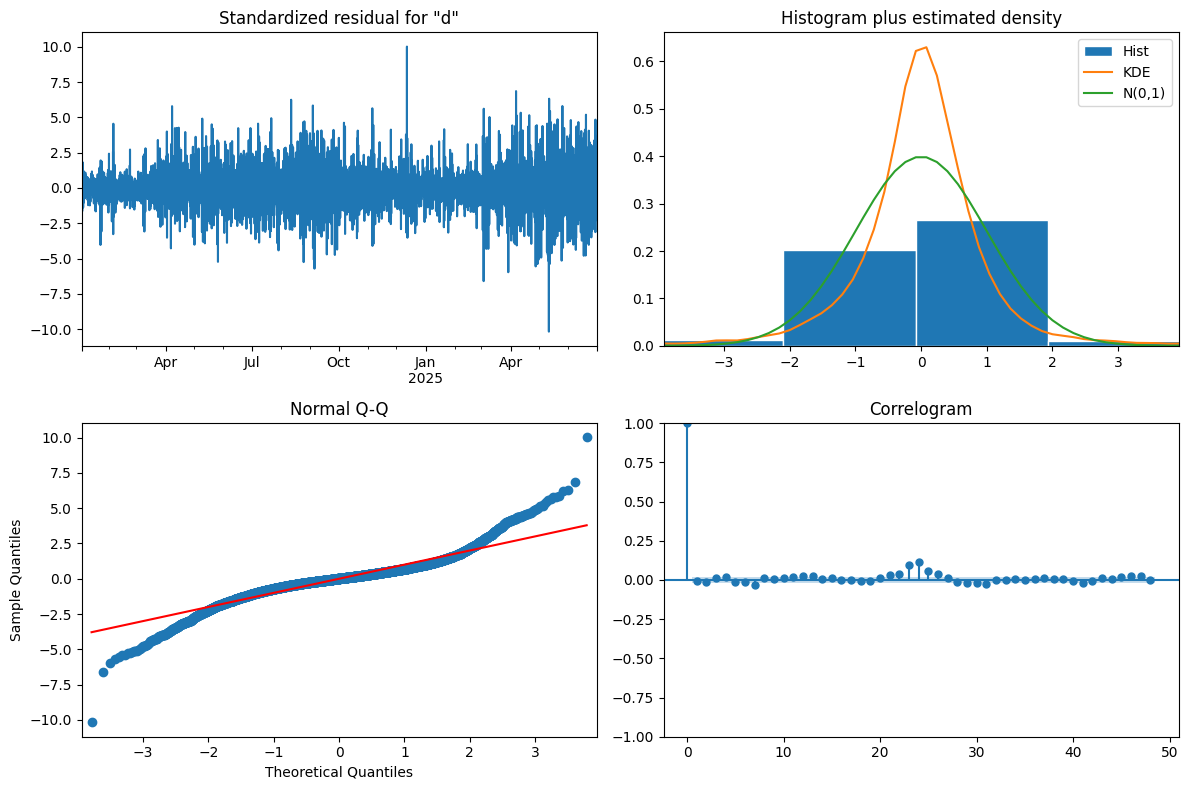

     lb_stat  lb_pvalue
24  396.2736     0.0000
48  513.6111     0.0000
168 839.5832     0.0000


In [22]:
# ── Post-fit diagnostic: are the residuals white noise? ──
# If the chosen order is adequate, residuals should contain no leftover structure
# (no trend, no autocorrelation). This validates the order AFTER refitting.
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1) Visual 4-panel check:
#    residuals over time | histogram vs N(0,1) | Q-Q plot | residual ACF (correlogram)
sarimax_fit.plot_diagnostics(figsize=(12, 8), lags=48)
plt.tight_layout()
plt.show()

In [29]:
from statsmodels.tsa.stattools import acf

# drop the first 24 residuals (state-space initialization artifacts)
r = acf(sarimax_fit.resid[24:], nlags=168)
for lag in [1, 2, 3, 24, 48, 168]:
    print(f"lag {lag:3d}: residual ACF = {r[lag]:+.3f}")

lag   1: residual ACF = -0.003
lag   2: residual ACF = -0.016
lag   3: residual ACF = +0.014
lag  24: residual ACF = +0.113
lag  48: residual ACF = +0.001
lag 168: residual ACF = +0.037


In [1]:
SARIMAX_ORDER    = (1, 0, 1)
SARIMAX_SEASONAL2 = (1, 1, 1, 24)

sarimax_iter = {"i": 0}
def sarimax_callback(params):
    sarimax_iter["i"] += 1
    if sarimax_iter["i"] == 1 or sarimax_iter["i"] % 5 == 0:
        print(f"SARIMAX iteration {sarimax_iter['i']}")

sarimax_spec2 = SARIMAX(
    endog=sarimax_endog_train,
    exog=sarimax_exog_train,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL2,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit2 = sarimax_spec2.fit(disp=True, maxiter=200, method="lbfgs", callback=sarimax_callback)
print(sarimax_fit2.summary())

NameError: name 'SARIMAX' is not defined

In [21]:
# save model
sarimax_fit.save("models/sarimax_fit.pkl")

In [26]:
# load model
sarimax_model = SARIMAXResults.load("models/sarimax_fit.pkl")

In [27]:
sarimax_endog_test = test_df[TARGET_COL].astype(np.float64)
sarimax_exog_test = test_df[SARIMAX_EXOG_COLS].astype(np.float64).ffill().bfill()

# Forecast one local delivery day at a time. DST days can have 23 or 25 hours.
test_dates = pd.date_range(
    start=TEST_START.normalize(),
    end=TEST_END.normalize() - pd.DateOffset(days=1),
    freq="D",
)

sarimax_preds_t = {}
running_res = sarimax_model  # starts from the end of the training data
n_days = len(test_dates)

for i, day in enumerate(test_dates):
    next_day = day + pd.DateOffset(days=1)
    day_mask = (sarimax_exog_test.index >= day) & (sarimax_exog_test.index < next_day)

    exog_day = sarimax_exog_test.loc[day_mask].sort_index().asfreq("h")

    if len(exog_day) == 0:
        print(f"WARNING: {day.date()} has no exog rows, skipping.")
        continue
    if exog_day.isna().any().any():
        print(f"WARNING: {day.date()} contains missing exog after hourly alignment, skipping.")
        continue

    # Multi-step forecast for the complete local delivery day.
    # Within this block SARIMAX uses its forecast dynamics, not actual same-day prices.
    steps = len(exog_day)
    forecast = running_res.get_forecast(steps=steps, exog=exog_day)
    for ts, val in forecast.predicted_mean.items():
        sarimax_preds_t[ts] = val

    actual_day = sarimax_endog_test.reindex(exog_day.index)
    if actual_day.isna().any():
        print(f"WARNING: {day.date()} contains missing actual target values, skipping state update.")
        continue

    running_res = running_res.extend(endog=actual_day, exog=exog_day)


sarimax_t = pd.Series(sarimax_preds_t, dtype=np.float64).sort_index().reindex(test_df.index)
if sarimax_t.isna().any():
    missing = int(sarimax_t.isna().sum())
    raise ValueError(f"SARIMAX forecast is missing {missing} test timestamps.")

sarimax = asinh_inverse(sarimax_t, c)
y_pred_sarimax = pd.DataFrame({"sarimax_pred": sarimax}, index=test_df.index)

print(f"SARIMAX  MAE={mae_score(y_test, sarimax.to_numpy()):.4f}  RMSE={rmse_score(y_test, sarimax.to_numpy()):.4f}")

SARIMAX  MAE=15.4267  RMSE=23.3108


In [28]:
sarimax_scores = pd.DataFrame([
    {"model": "sarimax", "mae": mae_score(y_test, y_pred_sarimax["sarimax_pred"]),
     "rmse": rmse_score(y_test, y_pred_sarimax["sarimax_pred"])}
])
scores = pd.concat([scores, sarimax_scores]).sort_values("mae")
display(scores)

,model,mae,rmse
0,xgb_lookback,14.6220,22.9862
1,xgb_point,14.7646,23.3732
2,xgb_rollout,14.8061,25.7780
3,rf_lookback,14.9553,24.7226
4,rf_point,15.0684,24.8588
5,svm_point,15.3998,24.7910
0,sarimax,15.4267,23.3108
6,bilstm,16.6881,25.9334
7,svm_lookback,16.6968,24.8262
8,rf_rollout,17.3090,28.8796


# Comparison

In [ ]:
display_scores = scores.copy()

models_to_keep = [
    "xgb_lookback",
    "xgb_rollout",
    "rf_lookback",
    "rf_rollout",
    "svm_lookback",
    "svm_rollout",
    "sarimax",
    "bilstm",
    "bilstm_rollout",
    "lstm",
    "lstm_rollout",
    "rf_point",
    "svm_point",
]
display_scores = display_scores[display_scores["model"].isin(models_to_keep)]

rename_map = {
    "xgb_lookback": "XGBoost Fixed",
    "xgb_rollout": "XGBoost Rollout",
    "rf_lookback": "RandomForest Fixed",
    "rf_rollout": "RandomForest Rollout",
    "svm_lookback": "SVM Fixed",
    "svm_rollout": "SVM Rollout",
    "sarimax": "SARIMAX",
    "bilstm": "BiLSTM Fixed",
    "bilstm_rollout": "BiLSTM Rollout",
    "lstm": "LSTM Fixed",
    "lstm_rollout": "LSTM Rollout",
    "rf_point": "RandomForest Point",
    "svm_point": "SVM Point",
}

display_scores["model"] = display_scores["model"].replace(rename_map)
display_scores = display_scores.reset_index(drop=True)
display_scores.index = display_scores.index + 1

display(display_scores)

#

# Counterfactual Analysis

In [ ]:
# --- DiCE Counterfactual Analysis mit Rücktransformation ---
import dice_ml
import pandas as pd
import numpy as np

# 1) Exog-only DataFrame
exog_names = FEATURE_COLS
X_train_exog_df = pd.DataFrame(X_train_exog_lookback, columns=exog_names)
X_test_exog_df  = pd.DataFrame(X_test_exog_lookback,  columns=exog_names)

features_to_vary = ['load_fc', 'gen_fc_wind_on', 'gen_fc_wind_off', 'gen_fc_solar']

# 2) Rücktransformations-Helfer
def inverse_transform_exog(df_scaled, scaler, scale_cols, all_cols):
    """Transformiert einen exog-DataFrame zurück in Originaleinheiten."""
    df_orig = df_scaled.copy()
    # Nur SCALE_COLS rücktransformieren (die anderen sind schon in Originaleinheiten)
    scale_idx = [all_cols.index(c) for c in scale_cols]
    arr = df_orig.values.copy()
    arr[:, scale_idx] = scaler.inverse_transform(arr[:, scale_idx])
    return pd.DataFrame(arr, columns=all_cols, index=df_orig.index)

# 3) Wrapper: 12 exog Features → 180 Features → Prediction → EUR/MWh
class ExogWrapper:
    def __init__(self, model, frozen_lags):
        self.model = model
        self.frozen_lags = frozen_lags

    def predict(self, X_exog):
        X_exog = np.array(X_exog)
        lags = np.broadcast_to(self.frozen_lags, (X_exog.shape[0], 168))
        pred_transformed = self.model.predict(np.concatenate([lags, X_exog], axis=1))
        return pred_transformed

# 4) Query wählen
pred_test = xgb_lookback.predict(X_test_flat_lookback)
query_idx = np.argmin(np.abs(pred_test - np.percentile(pred_test, 50)))
query_exog = X_test_exog_df.iloc[[query_idx]]
frozen_lags = X_test_flat_lookback[query_idx, :168].reshape(1, -1)

orig_pred = pred_test[query_idx]
print(f"Original Prediction: {asinh_inverse(orig_pred, c):.2f} EUR/MWh")

# 5) DiCE Setup
wrapper = ExogWrapper(xgb_lookback, frozen_lags)

d = dice_ml.Data(
    dataframe=pd.concat([X_train_exog_df, pd.Series(y_train_lookback, name='target')], axis=1),
    continuous_features=exog_names,
    outcome_name='target'
)
m = dice_ml.Model(model=wrapper, backend='sklearn', model_type='regressor')
exp = dice_ml.Dice(d, m, method='genetic')

desired_lower = [orig_pred * 0.7, orig_pred * 0.8]

cfs = exp.generate_counterfactuals(
    query_exog,
    total_CFs=3,
    desired_range=desired_lower,
    features_to_vary=features_to_vary,
)

# ============================================================
# 6) Ergebnisse rücktransformiert anzeigen
# ============================================================
cf_df_scaled = cfs.cf_examples_list[0].final_cfs_df  # Scaled CFs von DiCE

# --- Target (Prediction) rücktransformieren ---
cf_preds_scaled = wrapper.predict(cf_df_scaled[exog_names].values)
cf_preds_eur = [asinh_inverse(p, c) for p in cf_preds_scaled]

# --- Exogene Features rücktransformieren ---
query_orig = inverse_transform_exog(query_exog, scaler, SCALE_COLS, exog_names)
cf_orig    = inverse_transform_exog(cf_df_scaled[exog_names], scaler, SCALE_COLS, exog_names)

# --- Übersichtliche Ausgabe ---
print("\n" + "="*70)
print(f"ORIGINAL INSTANCE (Prediction: {asinh_inverse(orig_pred, c):.2f} EUR/MWh)")
print("="*70)
for feat in features_to_vary:
    print(f"  {feat:20s}: {query_orig[feat].values[0]:>10.2f}")

for i in range(len(cf_orig)):
    print(f"\n--- Counterfactual {i+1}  (Prediction: {cf_preds_eur[i]:.2f} EUR/MWh) ---")
    for feat in features_to_vary:
        orig_val = query_orig[feat].values[0]
        cf_val   = cf_orig[feat].values[i]
        delta    = cf_val - orig_val
        if abs(delta) > 1e-3:
            print(f"  {feat:20s}: {orig_val:>10.2f}  →  {cf_val:>10.2f}  ({delta:+.2f})")
        else:
            print(f"  {feat:20s}: {orig_val:>10.2f}  (unchanged)")


Original Prediction: 94.42 EUR/MWh


100%|██████████| 1/1 [00:00<00:00,  2.94it/s]


ORIGINAL INSTANCE (Prediction: 94.42 EUR/MWh)
  load_fc             :  178772.77
  gen_fc_wind_on      :    1917.68
  gen_fc_wind_off     :     335.75
  gen_fc_solar        :      17.29

--- Counterfactual 1  (Prediction: 64.40 EUR/MWh) ---
  load_fc             :  178772.77  →   123572.22  (-55200.55)
  gen_fc_wind_on      :    1917.68  →    21593.79  (+19676.10)
  gen_fc_wind_off     :     335.75  →       69.90  (-265.85)
  gen_fc_solar        :      17.29  →        0.36  (-16.93)

--- Counterfactual 2  (Prediction: 63.94 EUR/MWh) ---
  load_fc             :  178772.77  →   123572.22  (-55200.55)
  gen_fc_wind_on      :    1917.68  →    21593.79  (+19676.10)
  gen_fc_wind_off     :     335.75  →      699.67  (+363.92)
  gen_fc_solar        :      17.29  →        0.36  (-16.93)

--- Counterfactual 3  (Prediction: 66.75 EUR/MWh) ---
  load_fc             :  178772.77  →   148936.95  (-29835.81)
  gen_fc_wind_on      :    1917.68  →    21593.79  (+19676.10)
  gen_fc_wind_off     :     

In [ ]:
importances = xgb_lookback.feature_importances_  # (180,)

# Alle Preis-Lag-Features zusammen (168 Lookback + 3 einzelne Lags)
lag_idx = list(range(168))  # Lookback
lag_idx += [exog_names.index(f) + 168 for f in ['price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'load_fc']]
lag_importance = importances[lag_idx].sum()

# Die 4 actionable Features
actionable_names = ['load_fc', 'gen_fc_wind_on', 'gen_fc_wind_off', 'gen_fc_solar']
actionable_idx = [exog_names.index(f) + 168 for f in actionable_names]
actionable_importance = importances[actionable_idx].sum()

# Zeitliche Features
temporal_names = ['weekday_sin', 'weekday_cos', 'hour_sin', 'hour_cos', 'holiday_not_sunday']
temporal_idx = [exog_names.index(f) + 168 for f in temporal_names]
temporal_importance = importances[temporal_idx].sum()

print(f"Preis-Lags (168 + 3):   {lag_importance:.1%}")
print(f"Actionable (4):         {actionable_importance:.1%}")
print(f"Temporal (5):           {temporal_importance:.1%}")



Preis-Lags (168 + 3):   85.0%
Actionable (4):         6.4%
Temporal (5):           10.1%


#_______________________________________________________________________________________


In [ ]:
import plotly.graph_objects as go

y_true = np.asarray(y_test).reshape(-1)
y_pred_fixed = np.asarray(y_pred_xgb_lookback).reshape(-1)
y_pred_rollout = np.asarray(y_pred_xgb_rollout).reshape(-1)

n = min(len(y_true), len(y_pred_fixed), len(y_pred_rollout), len(ts_test_lookback))
df_plot = pd.DataFrame(
    {
        "Ist": y_true[:n],
        "XGB Fixed": y_pred_fixed[:n],
        "XGB Rollout": y_pred_rollout[:n],
    },
    index=ts_test_lookback[:n],
)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot["Ist"], mode="lines", name="Ist"))
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot["XGB Fixed"], mode="lines", name="XGB Fixed"))
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot["XGB Rollout"], mode="lines", name="XGB Rollout"))

fig.update_layout(
    title="Ist vs. XGB fixed/rollout (interaktiv zoombar)",
    xaxis_title="Zeit",
    yaxis_title="Preis [EUR/MWh]",
    template="plotly_white",
    hovermode="x unified",
    height=700,
)
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(buttons=[
        dict(count=1, label="1d", step="day", stepmode="backward"),
        dict(count=7, label="7d", step="day", stepmode="backward"),
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(step="all", label="Alles"),
    ]),
)
fig.show()